
# Burn-in solver diagnostic: raw head-counts vs. nondimensionalized (scaled) state

**Purpose.** Round 4 of the debugging pass found the 80-year burn-in blowing up
(`S`, `E` diverging to ~1e15-1e17 with opposite sign) around calendar year
1877-1878, for both a "flat" and a "biennial" (R0≈20, `beta_1=0.28`) candidate,
regardless of Jacobian source (analytic vs finite-difference). Leading
hypothesis: the ~100x population disparity across age groups (~20k in the
youngest group vs ~1.6M in the oldest), combined with a naive 1-infected seed
against R0≈15-20, produces a genuinely badly-scaled/stiff early transient that
no amount of `atol`/Jacobian tuning on the *raw head-count* state fully fixes.

This notebook runs the **same failing case** two ways -- raw state (people)
and nondimensionalized state (fraction of a fixed per-group reference
population, via `src.scaling`, an exact diagonal change of variables, see
that module's docstring) -- across several solver configurations, and
records per-year diagnostics so the two are directly comparable.

**Nothing here changes the model.** `scaling.py` wraps `model.ode_system` /
`jacobian.jac_ode_system` with a fixed diagonal rescaling; the wrapper's
self-consistency (rhs and Jacobian both match the raw system to machine
precision / ~1e-9 relative error under finite-difference cross-check) is
verified in the project handoff notes and reproduced briefly in the first
code cell below as a sanity gate before trusting anything downstream.


In [1]:

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from src import config, model, jacobian, scaling, historical_population as hpop

A = config.N_AGE_GROUPS
pd.set_option("display.width", 140)



## 0. Sanity gate: confirm the scaling wrapper is exact

Before trusting any raw-vs-scaled comparison below, re-verify that
`scaling.make_scaled_ode_system` / `make_scaled_jac` reproduce the raw
system exactly (not approximately) at a representative mid-burn-in state.
If this cell doesn't pass, stop -- everything below is meaningless.


In [2]:

_rng = np.random.default_rng(0)
_ref_test = np.array([20_000, 300_000, 300_000, 300_000, 300_000, 1_600_000])[:A].astype(float)
_D_test = scaling.build_reference_scale(_ref_test, A)

_M = _ref_test * 0.05; _S = _ref_test * 0.6; _E = _ref_test * 0.001
_I = _ref_test * 0.0005; _R = _ref_test * 0.3; _C = _ref_test * 0.01
_y = model.pack_state(_M, _S, _E, _I, _R, _C)

_params_test = {
    "beta_0": 800.0, "beta_1": 0.15, "phi": 0.0,
    "gamma": config.FIXED_GAMMA_PER_YEAR,
    "sigma": config.FIXED_SIGMA_PER_YEAR,
    "maternal_waning_rate": config.FIXED_MATERNAL_WANING_RATE_PER_YEAR,
    "birth_rate": 0.02, "death_rate": 0.01,
    "vaccination_rates": np.zeros(A - 1),
    "contact_matrix": np.eye(A),
}
_t = 3.7

_raw_rhs = model.ode_system(_t, _y, _params_test)
_x = scaling.scale_state(_y, _D_test)
_scaled_rhs_fn = scaling.make_scaled_ode_system(_D_test)
_sx = _scaled_rhs_fn(_t, _x, _params_test)
_rhs_err = np.max(np.abs(_sx - _raw_rhs / _D_test) / np.maximum(np.abs(_raw_rhs / _D_test), 1e-12))

_Jraw = jacobian.jac_ode_system(_t, _y, _params_test)
_Jscaled = scaling.make_scaled_jac(_D_test)(_t, _x, _params_test)
_Jexpected = (_Jraw * _D_test[None, :]) / _D_test[:, None]
_jac_err = np.max(np.abs(_Jscaled - _Jexpected))

print(f"rhs wrapper max relative error:      {_rhs_err:.3e}  (must be ~0)")
print(f"jacobian wrapper max abs error:       {_jac_err:.3e}  (must be ~0)")
assert _rhs_err < 1e-9 and _jac_err < 1e-9, "scaling wrapper is NOT exact -- stop and debug scaling.py"
print("OK -- scaling wrapper verified exact. Proceeding.")


rhs wrapper max relative error:      0.000e+00  (must be ~0)
jacobian wrapper max abs error:       0.000e+00  (must be ~0)
OK -- scaling wrapper verified exact. Proceeding.



## 1. Reconstruct the failing burn-in case

Same setup as Round 4: an 80-year burn-in (adjust `BURN_IN_YEARS` /
`FIT_START_YEAR` to match whatever the live diagnosis used), naive
initial condition (1 infected individual in the youngest age group), and
the two candidates that were previously found to fail --
a "flat" low-R0 candidate and the "biennial" R0≈20, `beta_1=0.28` candidate.

The reference population vector for the scaled runs is built from the
same naive initial condition's per-group totals -- fixed once, before
integration starts, per `scaling.build_reference_scale`'s docstring
(using the *live* N_a(t) instead would reintroduce a nonlinear coupling
and defeat the point).


In [3]:

FIT_START_YEAR = 1950
BURN_IN_YEARS = 80.0
BURN_IN_START_YEAR = FIT_START_YEAR - BURN_IN_YEARS

contact_df = hpop.contact_matrix.load_processed_contact_matrix()
contact = np.asarray(contact_df, dtype=float)
hpop.contact_matrix.validate_contact_matrix(contact_df)
print("contact matrix loaded, shape", contact.shape,
      "spectral radius", np.max(np.abs(np.linalg.eigvals(contact))))

gamma = config.FIXED_GAMMA_PER_YEAR
sigma = config.FIXED_SIGMA_PER_YEAR
delta = config.FIXED_MATERNAL_WANING_RATE_PER_YEAR

CANDIDATES = {
    "flat":     {"beta_0": config.PARAMETER_BOUNDS["beta_0"][0], "beta_1": 0.05, "phi": 0.0},
    "biennial": {"beta_0": 20.0 * gamma,                          "beta_1": 0.28, "phi": 0.0},
}
for name, c in CANDIDATES.items():
    print(f"{name:>9s}: beta_0={c['beta_0']:.2f}  R0={c['beta_0']/gamma:.2f}  beta_1={c['beta_1']}")

naive_ic = hpop.initial_conditions_for_population(
    hpop.population_for_year(BURN_IN_START_YEAR),
    seed_infected_per_group=1.0,
    seed_group_index=0,
)
ref_population_per_group = (
    naive_ic["M0"] + naive_ic["S0"] + naive_ic["E0"] + naive_ic["I0"] + naive_ic["R0"]
)
print("\nper-group reference population (naive IC):")
for label, pop in zip(config.AGE_GROUP_LABELS, ref_population_per_group):
    print(f"  {label:>4s}: {pop:,.0f}")
print(f"\nmax/min ratio across groups: {ref_population_per_group.max()/ref_population_per_group.min():.1f}x")


contact matrix loaded, shape (6, 6) spectral radius 1.0000000000000002
     flat: beta_0=547.88  R0=12.00  beta_1=0.05
 biennial: beta_0=913.12  R0=20.00  beta_1=0.28

per-group reference population (naive IC):
   0-1: 17,921
   1-2: 18,260
   2-3: 19,007
   3-4: 19,860
   4-5: 20,686
    5+: 1,437,987

max/min ratio across groups: 80.2x



## 2. Run every (solver config) × (raw / scaled) × (candidate) combination

Each run is wrapped so a hard failure (solver reports `success=False`,
or a raised exception from an eval cap / overflow) doesn't kill the loop --
we want the comparison table even when most configs fail. For each run we
record:

- success/failure and the solver's own message
- wall-clock time and number of rhs evaluations
- the **first year at which any raw-space compartment magnitude exceeds
  a sanity threshold** (1e9 -- utterly implausible for a human population),
  as a blow-up detector independent of whether solve_ivp itself calls it
  a "failure"
- min/max of `S` and `E` (raw head-count-equivalent, i.e. scaled runs are
  unscaled by `D` before this check) at the last successfully reached point

`t_eval` is a fine grid (8 points/year) so the blow-up can be localized to
roughly the same resolution as Round 4's diagnosis.


In [4]:

N_POINTS_PER_YEAR = 8
times = np.linspace(0.0, BURN_IN_YEARS, int(BURN_IN_YEARS * N_POINTS_PER_YEAR) + 1)
BLOWUP_THRESHOLD = 1e9  # head-count-equivalent; population of Texas was never within 4 orders of this

def birth_death_fns(cfg=config):
    birth_fn, death_fn = hpop.build_vital_rate_functions()
    def birth_of_t(t):
        return birth_fn(BURN_IN_START_YEAR + t)
    def death_of_t(t):
        return death_fn(BURN_IN_START_YEAR + t)
    return birth_of_t, death_of_t

birth_of_t, death_of_t = birth_death_fns()

def make_params(beta_0, beta_1, phi):
    return {
        "beta_0": beta_0, "beta_1": beta_1, "phi": phi,
        "gamma": gamma, "sigma": sigma, "maternal_waning_rate": delta,
        "birth_rate": birth_of_t, "death_rate": death_of_t,
        "vaccination_rates": np.zeros(A - 1),
        "contact_matrix": contact,
    }

# atol array for the raw system: looser for the large M/S/R compartments,
# tighter for E/I, same spirit as Round 3 -- included as a baseline
# "best effort tuning of the raw system" to compare against the scaled
# system's performance with a single scalar atol.
def raw_atol_array():
    per_group_atol = np.where(ref_population_per_group > 1e6, 1e-1, 1e-2)
    # tighter for E, I (indices 2,3 of the 6 compartment blocks)
    atol = np.concatenate([
        np.full(A, 1e2),   # M
        np.full(A, 1e2),   # S
        np.full(A, 1e-3),  # E
        np.full(A, 1e-3),  # I
        np.full(A, 1e2),   # R
        np.full(A, 1e-3),  # CumInc
    ])
    return atol

SOLVER_CONFIGS = [
    # (label, space, method, use_jac, atol, rtol)
    ("RK45 / scalar atol (original default)",       "raw",    "RK45",  False, 1e-6,   1e-6),
    ("LSODA / scalar atol",                          "raw",    "LSODA", False, 1e-3,   1e-6),
    ("LSODA / per-compartment atol array",           "raw",    "LSODA", False, "array",1e-6),
    ("Radau / analytic Jacobian / atol array",       "raw",    "Radau", True,  "array",1e-6),
    ("LSODA / analytic Jacobian / atol array",       "raw",    "LSODA", True,  "array",1e-6),
    ("BDF   / analytic Jacobian / atol array",       "raw",    "BDF",   True,  "array",1e-6),
    ("RK45 / scaled / scalar atol",                  "scaled", "RK45",  False, 1e-6,   1e-6),
    ("LSODA / scaled / scalar atol",                 "scaled", "LSODA", False, 1e-6,   1e-6),
    ("Radau / scaled / analytic Jacobian",           "scaled", "Radau", True,  1e-6,   1e-6),
    ("LSODA / scaled / analytic Jacobian",           "scaled", "LSODA", True,  1e-6,   1e-6),
    ("BDF   / scaled / analytic Jacobian",           "scaled", "BDF",   True,  1e-6,   1e-6),
]

MAX_RHS_EVALS = 500_000
D = scaling.build_reference_scale(ref_population_per_group, A)

def run_one(label, space, method, use_jac, atol_spec, rtol, params):
    atol = raw_atol_array() if atol_spec == "array" else atol_spec
    t0 = time.perf_counter()
    n_evals = [0]

    if space == "raw":
        y0 = model.pack_state(
            naive_ic["M0"], naive_ic["S0"], naive_ic["E0"],
            naive_ic["I0"], naive_ic["R0"], np.zeros(A),
        )
        def rhs(t, y, p):
            n_evals[0] += 1
            if n_evals[0] > MAX_RHS_EVALS:
                raise RuntimeError("max_rhs_evals exceeded")
            return model.ode_system(t, y, p)
        jac = jacobian.jac_ode_system if use_jac else None
    else:
        scaled_ic = scaling.scale_ic(
            {**naive_ic, "CumInc0": np.zeros(A)}, D, A
        )
        y0 = model.pack_state(
            scaled_ic["M0"], scaled_ic["S0"], scaled_ic["E0"],
            scaled_ic["I0"], scaled_ic["R0"], scaled_ic["CumInc0"],
        )
        scaled_rhs = scaling.make_scaled_ode_system(D)
        def rhs(t, x, p):
            n_evals[0] += 1
            if n_evals[0] > MAX_RHS_EVALS:
                raise RuntimeError("max_rhs_evals exceeded")
            return scaled_rhs(t, x, p)
        jac = scaling.make_scaled_jac(D) if use_jac else None

    result = dict(label=label, space=space, method=method, use_jac=use_jac,
                   candidate=None, success=False, message="", wall_s=None,
                   n_rhs_evals=None, first_blowup_year=None,
                   last_S_min=None, last_S_max=None, last_E_min=None, last_E_max=None)

    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            sol = solve_ivp(
                fun=rhs, t_span=(times[0], times[-1]), y0=y0, t_eval=times,
                args=(params,), method=method, jac=jac, atol=atol, rtol=rtol,
            )
        result["success"] = bool(sol.success)
        result["message"] = sol.message + ("".join(f" | WARN: {w.message}" for w in caught) if caught else "")
    except Exception as exc:  # noqa: BLE001 -- deliberately broad, this is a diagnostic harness
        result["message"] = f"raised {type(exc).__name__}: {exc}"
        sol = None

    result["wall_s"] = time.perf_counter() - t0
    result["n_rhs_evals"] = n_evals[0]

    if sol is not None and sol.y.shape[1] > 0:
        Y = sol.y * D[:, None] if space == "scaled" else sol.y
        S_block = Y[A:2 * A, :]
        E_block = Y[2 * A:3 * A, :]
        max_abs_over_time = np.max(np.abs(Y), axis=0)
        blowup_idx = np.argmax(max_abs_over_time > BLOWUP_THRESHOLD) if np.any(max_abs_over_time > BLOWUP_THRESHOLD) else None
        if blowup_idx:
            result["first_blowup_year"] = float(sol.t[blowup_idx])
        result["last_S_min"], result["last_S_max"] = float(S_block[:, -1].min()), float(S_block[:, -1].max())
        result["last_E_min"], result["last_E_max"] = float(E_block[:, -1].min()), float(E_block[:, -1].max())

    return result


In [5]:

rows = []
for cand_name, cand_params in CANDIDATES.items():
    params = make_params(**cand_params)
    for (label, space, method, use_jac, atol_spec, rtol) in SOLVER_CONFIGS:
        print(f"running: [{cand_name:>9s}] {label} ...", end=" ", flush=True)
        r = run_one(label, space, method, use_jac, atol_spec, rtol, params)
        r["candidate"] = cand_name
        rows.append(r)
        status = "OK" if r["success"] else "FAIL"
        print(f"{status}  ({r['wall_s']:.1f}s, {r['n_rhs_evals']} evals)"
              + (f"  blew up @ year {r['first_blowup_year']:.1f}" if r["first_blowup_year"] else ""))

diagnostics = pd.DataFrame(rows)


running: [     flat] RK45 / scalar atol (original default) ... OK  (0.8s, 23030 evals)
running: [     flat] LSODA / scalar atol ... OK  (0.4s, 10928 evals)
running: [     flat] LSODA / per-compartment atol array ... FAIL  (14.8s, 500001 evals)
running: [     flat] Radau / analytic Jacobian / atol array ... FAIL  (23.9s, 500001 evals)
running: [     flat] LSODA / analytic Jacobian / atol array ... FAIL  (35.1s, 500001 evals)
running: [     flat] BDF   / analytic Jacobian / atol array ... OK  (0.0s, 625 evals)
running: [     flat] RK45 / scaled / scalar atol ... FAIL  (0.3s, 10154 evals)
running: [     flat] LSODA / scaled / scalar atol ... OK  (0.3s, 8281 evals)
running: [     flat] Radau / scaled / analytic Jacobian ... FAIL  (24.0s, 500001 evals)
running: [     flat] LSODA / scaled / analytic Jacobian ... OK  (0.1s, 2862 evals)
running: [     flat] BDF   / scaled / analytic Jacobian ... OK  (0.3s, 5144 evals)
running: [ biennial] RK45 / scalar atol (original default) ... OK  (1.1s, 35


## 4. Per-year trajectory diagnostics for the best raw config vs. best scaled config

Pick the best-performing raw-space run and the best-performing scaled-space
run per candidate (by: success first, then latest blow-up year, then fewest
evals) and plot `max(|S|)`, `max(|E|)` across age groups on a log scale over
the burn-in window -- this is the same diagnostic view Round 4 used manually
to localize the ~1877-1878 blow-up, now generated automatically for
side-by-side comparison.


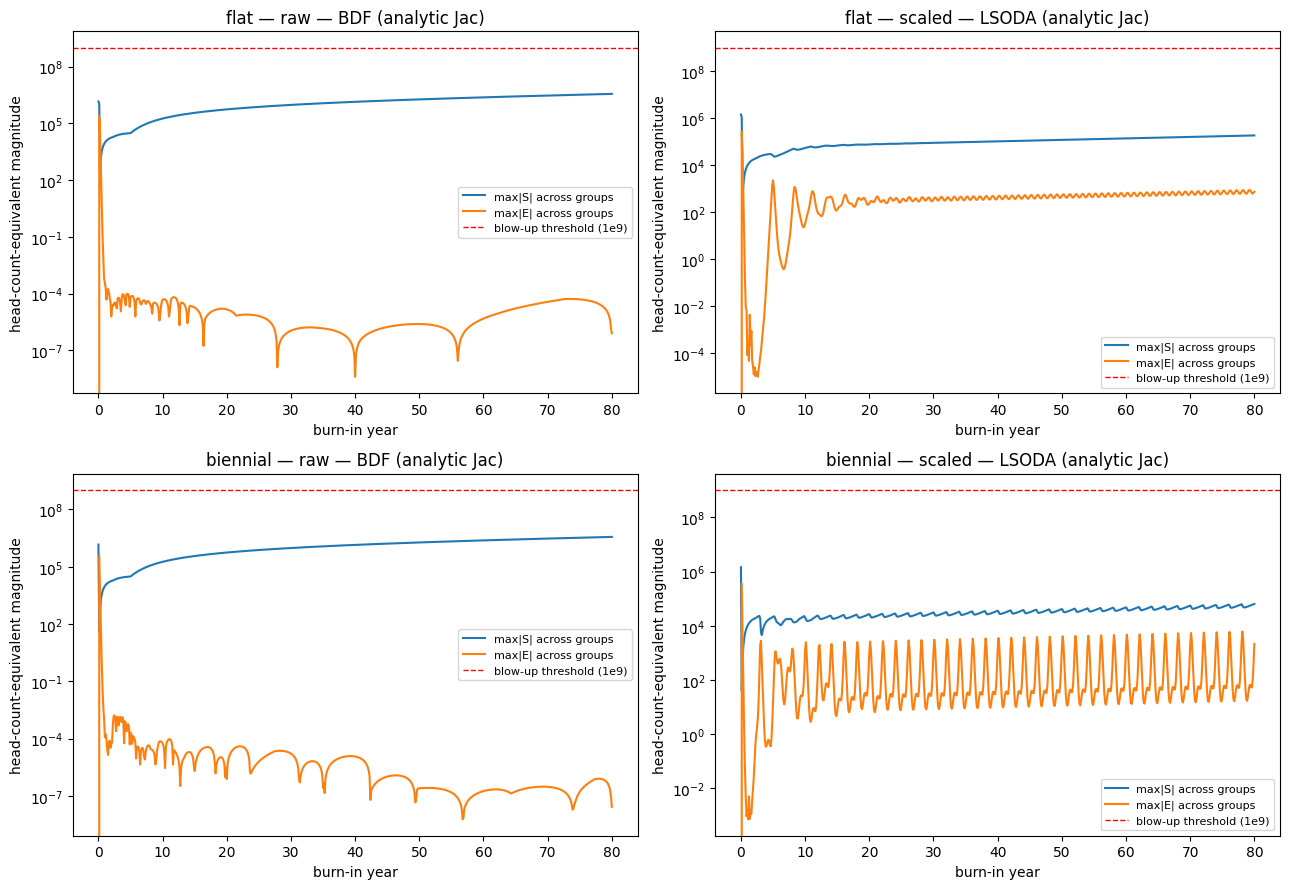

In [8]:

def rerun_for_trace(row, params):
    # Re-run the chosen config once more, this time keeping the full sol
    # object (the loop above only kept summary stats) so we can plot it.
    space = row["space"]
    method = row["method"]
    use_jac = row["use_jac"]
    atol_spec = "array" if "atol array" in row["label"] or "atol_array" in row["label"] else \
                (1e-3 if space == "raw" and method == "LSODA" and "array" not in row["label"] else 1e-6)
    # NOTE: this re-derivation of atol_spec from the label is a convenience
    # for this notebook only -- for a permanent script, thread atol_spec
    # through the results dict instead of re-parsing the label string.
    r = run_one(row["label"], space, method, use_jac, atol_spec, 1e-6, params)
    return r

fig, axes = plt.subplots(len(CANDIDATES), 2, figsize=(13, 4.5 * len(CANDIDATES)), squeeze=False)

for i, (cand_name, cand_params) in enumerate(CANDIDATES.items()):
    params = make_params(**cand_params)
    cand_rows = diagnostics[diagnostics["candidate"] == cand_name]

    def rank(r):
        return (0 if r["success"] else 1, -(r["first_blowup_year"] or BURN_IN_YEARS), r["n_rhs_evals"])

    best_raw = min(cand_rows[cand_rows["space"] == "raw"].to_dict("records"), key=rank)
    best_scaled = min(cand_rows[cand_rows["space"] == "scaled"].to_dict("records"), key=rank)

    for j, best in enumerate([best_raw, best_scaled]):
        ax = axes[i][j]
        space = best["space"]
        y0 = (model.pack_state(naive_ic["M0"], naive_ic["S0"], naive_ic["E0"],
                                naive_ic["I0"], naive_ic["R0"], np.zeros(A))
              if space == "raw" else
              model.pack_state(*[scaling.scale_ic({**naive_ic, "CumInc0": np.zeros(A)}, D, A)[k]
                                  for k in ("M0", "S0", "E0", "I0", "R0", "CumInc0")]))
        rhs = model.ode_system if space == "raw" else scaling.make_scaled_ode_system(D)
        jac = (jacobian.jac_ode_system if best["use_jac"] else None) if space == "raw" else \
              (scaling.make_scaled_jac(D) if best["use_jac"] else None)
        atol = raw_atol_array() if (space == "raw" and "array" in best["label"]) else 1e-6
        try:
            sol = solve_ivp(fun=rhs, t_span=(times[0], times[-1]), y0=y0, t_eval=times,
                             args=(params,), method=best["method"], jac=jac, atol=atol, rtol=1e-6)
        except Exception as exc:
            print(f"[{cand_name} / {space}] re-run raised {exc}; skipping plot")
            continue

        Y = sol.y * D[:, None] if space == "scaled" else sol.y
        S_block, E_block = Y[A:2 * A, :], Y[2 * A:3 * A, :]
        ax.semilogy(sol.t, np.max(np.abs(S_block), axis=0), label="max|S| across groups")
        ax.semilogy(sol.t, np.max(np.abs(E_block), axis=0), label="max|E| across groups")
        ax.axhline(BLOWUP_THRESHOLD, color="red", ls="--", lw=1, label="blow-up threshold (1e9)")
        ax.set_title(f"{cand_name} — {space} — {best['method']}"
                     + (" (analytic Jac)" if best["use_jac"] else ""))
        ax.set_xlabel("burn-in year")
        ax.set_ylabel("head-count-equivalent magnitude")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



## 5. Reading the result

- If **every scaled-space row succeeds** (or at minimum survives far past
  ~year 4 without crossing the blow-up threshold) while raw-space rows
  keep failing near the same early year regardless of solver/Jacobian,
  that's a direct confirmation of the scale-disparity hypothesis, and the
  next step is to adopt `scaling.simulate_model_scaled` as the burn-in
  (and possibly fit-window) integration path going forward.
- If scaled-space **still** blows up at a similar point, the scale
  hypothesis is not the (whole) explanation -- next suspect per the
  handoff notes is the naive single-infected seed itself (try seeding
  proportional to population, or across multiple age groups, using this
  same harness) rather than continued solver/tolerance tuning.
- Either way, this table is the artifact to attach to that decision --
  it's a controlled comparison (same candidates, same solvers, same
  time grid) rather than another one-off manual run.
